In [ ]:
import os

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import pandas as pd
from pathlib import Path
import time
import gc
import random
import numpy as np
import tensorflow as tf
import plotly.express as px

from tensorflow.keras.applications import ResNet152, ResNet101
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow_recommenders as tfrs
from typing import Dict, Text, List, Tuple, Optional, Any
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tqdm import tqdm
from dataclasses import dataclass, field
import pickle

from datetime import datetime, timedelta

SEED = int(os.getenv("HNM_SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
start_time = time.time()

# Contents

## Section 1
1. Image Embedding

## Section 2
1. Data Loading and Preprocessing Pipeline
2. Train-Test Split
3. Feature Engineering and Preprocessing
4. Model Training 
5. Inference
6. Model Evaluation


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# Section 1

## Image Embedding

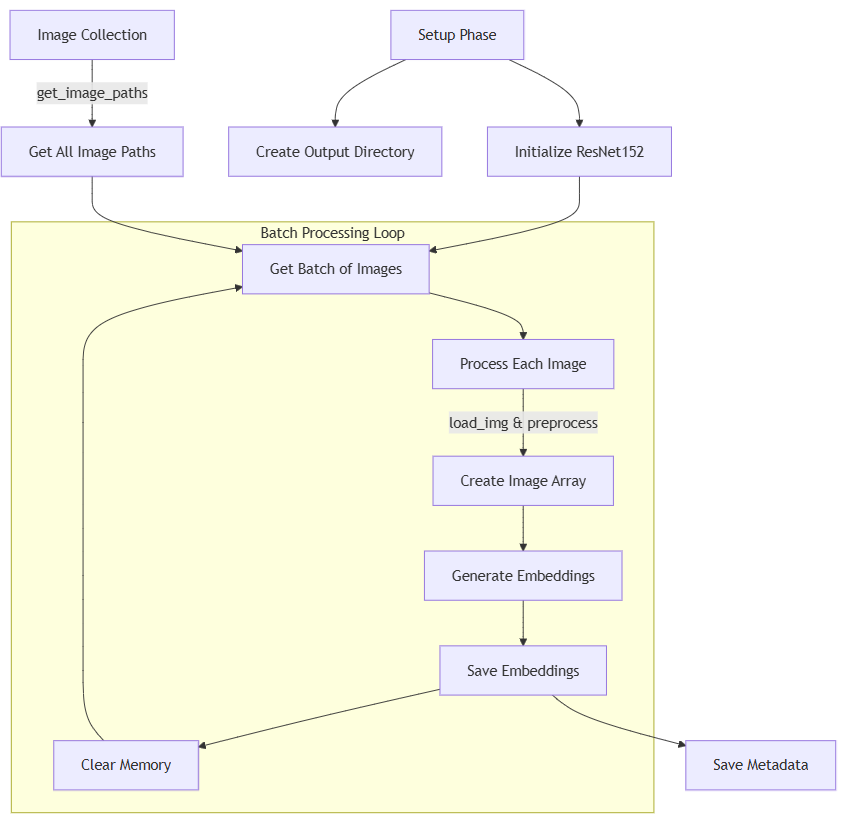

In [ ]:
import os
import numpy as np
from tensorflow.keras.applications import ResNet152, ResNet101
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import tensorflow as tf
import gc
from pathlib import Path

# Constants
IMAGE_DIR = Path(os.getenv("HNM_IMAGE_DIR", "./images"))
OUTPUT_DIR = Path(os.getenv("HNM_EMBEDDING_OUTPUT_DIR", "./embedded_images_resnet152"))
MAX_IMAGES = 106_000
BATCH_SIZE = 64

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def get_model():
    """
    Get the ResNet model without top layer
    Returns base model that outputs embeddings
    """
    base_model = ResNet152(
        include_top=False, weights="imagenet", pooling="avg"
    )  # 'avg' gives us 2048-dim vector
    return base_model


def process_image(image_path):
    """Load and preprocess single image"""
    try:
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)
        return img_array
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return None


def get_image_paths():
    """Get all image paths"""
    image_paths = []
    for root, _, files in os.walk(IMAGE_DIR):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg")):
                image_paths.append(os.path.join(root, file))
                if len(image_paths) >= MAX_IMAGES:
                    return image_paths
    return image_paths


def embed_images():
    if not IMAGE_DIR.exists():
        raise FileNotFoundError(
            f"Image directory does not exist: {IMAGE_DIR.resolve()}"
        )

    # Check for GPU
    physical_devices = tf.config.list_physical_devices("GPU")
    if physical_devices:
        print("GPU is available")
        # Allow memory growth for GPU
        for device in physical_devices:
            tf.config.experimental.set_memory_growth(device, True)
    else:
        print("No GPU found, using CPU")

    # Get model
    model = get_model()

    # Get image paths
    image_paths = get_image_paths()
    print(f"Found {len(image_paths)} images")

    # Process images in batches
    for i in tqdm(range(0, len(image_paths), BATCH_SIZE)):
        batch_paths = image_paths[i : i + BATCH_SIZE]

        # Process batch
        batch_images = []
        valid_paths = []

        for img_path in batch_paths:
            processed = process_image(img_path)
            if processed is not None:
                # Remove the extra dimension
                batch_images.append(processed[0])
                valid_paths.append(img_path)

        if not batch_images:
            continue

        # Convert to array and get embeddings
        batch_images = np.array(batch_images)
        batch_embeddings = model.predict(batch_images, verbose=0)

        # Save individual embeddings
        for img_path, embedding in zip(valid_paths, batch_embeddings):
            filename = os.path.basename(img_path)
            output_path = OUTPUT_DIR / f"{os.path.splitext(filename)[0]}.npy"
            np.save(output_path, embedding)

        # Clear memory- free up CPU memory
        del batch_images, batch_embeddings
        gc.collect()

    print(f"Embeddings saved to: {OUTPUT_DIR.resolve()}")


## Note to reviewer - Have not run this code in the python ipynb file as it takes a long time to run.


In [ ]:
# Execute the function
embed_images()

In [ ]:
# Output of one embedding

# Directory path
dir_path = Path(os.getenv("HNM_EMBEDDING_OUTPUT_DIR", "./embedded_images_resnet152"))

# Get a random .npy file
npy_files = [f for f in os.listdir(dir_path) if f.endswith('.npy')]
if not npy_files:
    raise FileNotFoundError(f"No .npy files found in {dir_path.resolve()}")

random_file = random.choice(npy_files)

# Load the embedding
embedding_path = dir_path / random_file
embedding = np.load(embedding_path)

print(f"File name: {random_file}")
print(f"Embedding shape: {embedding.shape}")
print("Values of embedding:", embedding)


+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# Section 2

# Data Loading and Preprocessing Pipeline

The data pipeline processes H&M's fashion retail dataset through three main stages:

1. Initial Data Loading:
Here we read input csv's and save them in a dictionary, and the dictionaries into a picke file. This is done to ssave time on subsequent data loads- we only need to load the pickle file from then on (if it exists). Loading pickle file is faster . This handles transaction records, customer information, and article details.

2. Data Type Management:
Ensures consistent data types across datasets, with careful handling of IDs, categorical variables, and missing values. Particular attention is paid to customer data integrity.

3. Dataset Filtering:
Processes the most recent N images (defined by us) transactions while maintaining referential integrity between customer and article datasets. Optionally incorporates article image embeddings for enhanced feature representation.

In [ ]:
def format_number(n):
    """Format number with commas after every 3 digits"""
    return f"{n:,}"


def read_csvs_to_dict(directory_path: str) -> Dict[str, pd.DataFrame]:
    """
    Read all CSV files from a directory into a dictionary where
    keys are filenames and values are pandas DataFrames
    """
    dir_path = Path(directory_path)
    csv_dict = {}

    try:
        for file_path in sorted(dir_path.glob("*.csv")):
            try:
                df = pd.read_csv(file_path)
                key = file_path.stem
                csv_dict[key] = df
                print(f"Successfully read: {file_path.name}")
            except Exception as e:
                print(f"Error reading {file_path.name}: {str(e)}")

        if not csv_dict:
            print("No CSV files found in the directory")

        return csv_dict

    except Exception as e:
        print(f"Error accessing directory: {str(e)}")
        return {}


def main_load_raw(directory_path: Optional[str] = None):
    directory = Path(
        directory_path
        or os.getenv("HNM_DATA_DIR", "./h-and-m-personalized-fashion-recommendations")
    )

    if not directory.exists():
        raise FileNotFoundError(f"Data directory not found: {directory.resolve()}")

    data_dict = read_csvs_to_dict(str(directory))

    print()
    print("Summary of loaded data:")
    for filename, df in data_dict.items():
        print()
        print(f"Filename: {filename}")
        print(
            f"Dimensions: ({format_number(df.shape[0])}, {format_number(df.shape[1])})"
        )
        print("Columns:", list(df.columns))
        print("Memory usage:", f"{df.memory_usage().sum() / 1024**2:.2f} MB")

    for filename, df in data_dict.items():
        print()
        print(f"Filename: {filename}")
        print("**********************************")

        id_like_columns = [
            col
            for col in df.columns
            if any(sub in col for sub in ["id", "code", "name", "no"])
        ]
        if id_like_columns:
            df[id_like_columns] = df[id_like_columns].astype(str)

        if filename == "customers":
            df[["FN", "Active"]] = df[["FN", "Active"]].fillna(0).astype(float)

        print(df.dtypes)

    return data_dict


def load_data(pkl_file: str = "data_dict2.pkl", data_dir: Optional[str] = None):
    """
    Load data from pkl file
    """
    pkl_path = Path(pkl_file)

    if pkl_path.exists():
        print("Loading data_dict from pkl file...")
        with pkl_path.open("rb") as f:
            data_dict = pickle.load(f)
            print(f"Loaded data_dict from {pkl_path}")
    else:
        print("No pkl file found. Loading raw data...")
        data_dict = main_load_raw(data_dir)
        with pkl_path.open("wb") as f:
            pickle.dump(data_dict, f)
            print(f"Saved data_dict to {pkl_path}")

    return data_dict


def filter_datasets(
    data_dict: Dict[str, pd.DataFrame],
    include_article_embeddings: bool = True,
    article_embedding_path: Optional[str] = None,
    max_transactions: Optional[int] = 50_000,
):
    """
    Filter datasets to include only transactions, customers, and articles
    """
    transactions_df = data_dict["transactions_train"].copy()
    customers_df = data_dict["customers"].copy()
    articles_df = data_dict["articles"].copy()

    if include_article_embeddings:
        embedding_path = article_embedding_path or os.getenv(
            "HNM_ARTICLE_EMBEDDINGS_PATH", "./article_embeddings.parquet"
        )

        print("Including article embeddings")
        article_embedding_df = pd.read_parquet(embedding_path)
        articles_df = pd.merge(
            articles_df, article_embedding_df, on="article_id", how="left"
        )

    transactions_df["t_dat"] = pd.to_datetime(transactions_df["t_dat"])
    transactions_df = transactions_df.sort_values("t_dat")

    if max_transactions is not None:
        transactions_df = transactions_df.tail(max_transactions)

    unique_customers, unique_items = (
        transactions_df["customer_id"].unique(),
        transactions_df["article_id"].unique(),
    )

    customers_df = customers_df.loc[customers_df["customer_id"].isin(unique_customers)]
    articles_df = articles_df.loc[articles_df["article_id"].isin(unique_items)]

    return (
        transactions_df.reset_index(drop=True),
        customers_df.reset_index(drop=True),
        articles_df.reset_index(drop=True),
    )


In [ ]:
def merge_list_of_datasets(datasets: List[pd.DataFrame]) -> pd.DataFrame:
    """Concatenate dataframes while resetting the index."""
    if not datasets:
        raise ValueError("`datasets` must contain at least one dataframe.")
    return pd.concat(datasets, ignore_index=True)


In [ ]:
# Load data (from cache if available).
data_dict = load_data(
    pkl_file=os.getenv("HNM_DATA_CACHE", "data_dict2.pkl"),
    data_dir=os.getenv("HNM_DATA_DIR"),
)


In [ ]:
print("data_dict keys:", list(data_dict.keys()))
print("customer df shape:", data_dict["customers"].shape)
print("transactions df shape:", data_dict["transactions_train"].shape)
print("articles df shape:", data_dict["articles"].shape)


In [ ]:
# Filter datasets.
article_embedding_path = os.getenv("HNM_ARTICLE_EMBEDDINGS_PATH")
include_article_embeddings = bool(article_embedding_path)
max_transactions = int(os.getenv("HNM_MAX_TRANSACTIONS", "50000"))

transactions_df, customers_df, articles_df = filter_datasets(
    data_dict,
    include_article_embeddings=include_article_embeddings,
    article_embedding_path=article_embedding_path,
    max_transactions=max_transactions,
)


In [ ]:
customers_df.head(5)

In [ ]:
articles_df.head(5)

In [ ]:
transactions_df.head(5)

# Train-Test Split

We implemented a temporal split that respects the chronological nature of purchases. This means we train on older data and test on newer data, mimicking how the system would work in real life. This approach helps us better understand how our model will perform with future purchases and seasonal trends.

In [ ]:
def create_temporal_split_percentage(
    transactions_df: pd.DataFrame,
    train_size: float = 0.70,
    val_size: float = 0.15,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Create a chronological train/validation/test split."""
    if not 0 < train_size < 1:
        raise ValueError("train_size must be in (0, 1)")
    if not 0 < val_size < 1:
        raise ValueError("val_size must be in (0, 1)")
    if train_size + val_size >= 1:
        raise ValueError("train_size + val_size must be < 1")

    sorted_df = transactions_df.sort_values("t_dat").reset_index(drop=True)

    n_transactions = len(sorted_df)
    train_end_idx = int(n_transactions * train_size)
    val_end_idx = int(n_transactions * (train_size + val_size))

    train_df = sorted_df.iloc[:train_end_idx].copy()
    val_df = sorted_df.iloc[train_end_idx:val_end_idx].copy()
    test_df = sorted_df.iloc[val_end_idx:].copy()

    print(
        "Train period:",
        train_df["t_dat"].min(),
        "to",
        train_df["t_dat"].max(),
    )
    print("Train shape:", train_df.shape)
    print("Validation shape:", val_df.shape)
    print("Test shape:", test_df.shape)

    return train_df, val_df, test_df


In [ ]:
# Train test split
train_df, val_df, test_df = create_temporal_split_percentage(transactions_df)

# Feature Engineering and Preprocessing

We built the feature engineering pipeline with two main parts to transform raw transaction data into meaningful features for our recommendation model:

1. Feature Engineering (`FeatureEngineer`):
  - Transforms customer data into useful metrics like purchasing frequency, average spend, and recent activity
  - Creates article features showing how popular items are, their typical prices, and sales patterns
  - Adds time-based features from transactions like day of week and seasonal patterns

2. Feature Preprocessing (`FeaturePreprocessor`):
  - Handles different types of data (numbers, categories, IDs) appropriately
  - Scales numerical features so they're comparable
  - Converts categorical features into a format the model can understand
  - Takes care of missing data and memory optimization
  - Ensures consistent processing across training and test data

The main function ties everything together, making sure each dataset (train, validation, test) is processed consistently while keeping their time-based separation intact.

In [ ]:
class FeatureEngineer:
    """Feature engineering for customers, articles, and interactions."""

    DEFAULT_CUSTOMER_DROP_COLUMNS = ["postal_code", "first_purchase", "last_purchase"]
    DEFAULT_ARTICLE_DROP_COLUMNS = [
        "product_code",
        "prod_name",
        "product_type_no",
        "graphical_appearance_no",
        "colour_group_code",
        "perceived_colour_value_id",
        "perceived_colour_master_id",
        "department_no",
        "department_name",
        "index_code",
        "index_group_no",
        "section_no",
        "garment_group_no",
        "detail_desc",
        "first_sale",
        "last_sale",
    ]

    def __init__(
        self,
        transactions_train: pd.DataFrame,
        transactions_val: pd.DataFrame,
        transactions_test: pd.DataFrame,
        articles_df: pd.DataFrame,
        customers_df: pd.DataFrame,
    ) -> None:
        self.transactions_train = transactions_train
        self.transactions_val = transactions_val
        self.transactions_test = transactions_test
        self.articles_df = articles_df
        self.customers_df = customers_df

    @staticmethod
    def _mode_or_nan(series: pd.Series):
        mode = series.mode(dropna=True)
        return mode.iloc[0] if not mode.empty else np.nan

    def engineer_customer_features(
        self,
        transactions_df: pd.DataFrame,
        end_date: datetime,
        cols_to_drop: Optional[List[str]] = None,
    ) -> pd.DataFrame:
        """Engineer customer-level features up to `end_date`."""
        cols_to_drop = cols_to_drop or self.DEFAULT_CUSTOMER_DROP_COLUMNS
        hist_transactions = transactions_df[transactions_df["t_dat"] <= end_date]

        customer_stats = (
            hist_transactions.groupby("customer_id")
            .agg(
                {
                    "t_dat": ["count", "min", "max"],
                    "price": ["mean", "std", "min", "max", "sum"],
                    "article_id": "nunique",
                    "sales_channel_id": self._mode_or_nan,
                }
            )
            .reset_index()
        )

        customer_stats.columns = [
            "customer_id",
            "purchase_count",
            "first_purchase",
            "last_purchase",
            "avg_price",
            "price_std",
            "min_price",
            "max_price",
            "total_spend",
            "unique_items",
            "preferred_channel",
        ]

        customer_stats["days_active"] = (
            customer_stats["last_purchase"] - customer_stats["first_purchase"]
        ).dt.days
        customer_stats["purchase_frequency"] = customer_stats["purchase_count"] / (
            customer_stats["days_active"] + 1
        )

        last_month = end_date - timedelta(days=30)
        recent_transactions = hist_transactions[hist_transactions["t_dat"] > last_month]
        recent_stats = (
            recent_transactions.groupby("customer_id")
            .agg({"t_dat": "count", "price": ["mean", "sum"]})
            .reset_index()
        )

        recent_stats.columns = [
            "customer_id",
            "recent_purchases",
            "recent_avg_price",
            "recent_spend",
        ]

        customer_features = customer_stats.merge(
            recent_stats, on="customer_id", how="left"
        )
        customer_features = customer_features.merge(
            self.customers_df, on="customer_id", how="left"
        )

        customer_features = customer_features.fillna(
            {"recent_purchases": 0, "recent_avg_price": 0, "recent_spend": 0}
        )
        customer_features = self.handle_nulls(customer_features)

        for col in cols_to_drop:
            customer_features = customer_features.drop(col, axis=1, errors="ignore")

        customer_features.columns = ["customer_id"] + [
            f"{col}_cust" for col in customer_features.columns if col != "customer_id"
        ]
        return customer_features

    def engineer_article_features(
        self,
        transactions_df: pd.DataFrame,
        end_date: datetime,
        cols_to_drop: Optional[List[str]] = None,
    ) -> pd.DataFrame:
        """Engineer article-level features up to `end_date`."""
        cols_to_drop = cols_to_drop or self.DEFAULT_ARTICLE_DROP_COLUMNS
        hist_transactions = transactions_df[transactions_df["t_dat"] <= end_date]

        article_stats = (
            hist_transactions.groupby("article_id")
            .agg(
                {
                    "t_dat": ["count", "min", "max"],
                    "customer_id": "nunique",
                    "price": ["mean", "std", "median"],
                    "sales_channel_id": self._mode_or_nan,
                }
            )
            .reset_index()
        )

        article_stats.columns = [
            "article_id",
            "total_sales",
            "first_sale",
            "last_sale",
            "unique_customers",
            "avg_price",
            "price_std",
            "median_price",
            "preferred_channel",
        ]

        last_month = end_date - timedelta(days=30)
        recent_transactions = hist_transactions[hist_transactions["t_dat"] > last_month]
        recent_stats = (
            recent_transactions.groupby("article_id")
            .agg({"t_dat": "count", "customer_id": "nunique"})
            .reset_index()
        )
        recent_stats.columns = ["article_id", "recent_sales", "recent_unique_customers"]

        article_features = article_stats.merge(recent_stats, on="article_id", how="left")
        article_features = article_features.merge(
            self.articles_df, on="article_id", how="left"
        )

        article_features = article_features.fillna(
            {"recent_sales": 0, "recent_unique_customers": 0}
        )
        article_features = self.handle_nulls(article_features)

        for col in cols_to_drop:
            article_features = article_features.drop(col, axis=1, errors="ignore")

        article_features.columns = ["article_id"] + [
            f"{col}_art" for col in article_features.columns if col != "article_id"
        ]
        return article_features

    def engineer_interaction_features(self, transactions_df: pd.DataFrame) -> pd.DataFrame:
        """Engineer transaction-level interaction features."""
        interactions = transactions_df.copy()

        interactions["day_of_week"] = interactions["t_dat"].dt.dayofweek
        interactions["month"] = interactions["t_dat"].dt.month
        interactions["day"] = interactions["t_dat"].dt.day
        interactions["is_weekend"] = interactions["day_of_week"].isin([5, 6]).astype(int)

        return self.handle_nulls(interactions)

    def create_all_features(
        self,
        target_df: pd.DataFrame,
        reference_date: Optional[datetime] = None,
    ) -> pd.DataFrame:
        """Create merged interaction + customer + article features."""
        if reference_date is None:
            reference_date = target_df["t_dat"].max()

        customer_features = self.engineer_customer_features(
            self.transactions_train, reference_date
        )
        article_features = self.engineer_article_features(
            self.transactions_train, reference_date
        )
        interaction_features = self.engineer_interaction_features(target_df)

        return interaction_features.merge(
            customer_features, on="customer_id", how="left"
        ).merge(article_features, on="article_id", how="left")

    def handle_nulls(self, df: pd.DataFrame) -> pd.DataFrame:
        """Fill nulls using feature-type-aware defaults."""
        for col in df.columns:
            if df[col].isnull().sum() == 0:
                continue

            if pd.api.types.is_numeric_dtype(df[col]):
                if df[col].nunique(dropna=True) <= 2:
                    df[col] = df[col].fillna(0)
                else:
                    df[col] = df[col].fillna(df[col].median())
            else:
                mode = df[col].mode(dropna=True)
                df[col] = df[col].fillna(mode.iloc[0] if not mode.empty else "unknown")

        return df


In [ ]:
class FeaturePreprocessor:
    """
    Scale and encode non-ID features while preserving join keys as-is.
    """

    def __init__(self):
        self.continuous_scaler = StandardScaler()
        self.categorical_encoders = {}
        self.continuous_features = []
        self.binary_features = []
        self.categorical_features = []
        self.fitted = False

    def _detect_feature_types(self, df):
        """
        Automatically detect feature types from dataframe.
        Returns lists of continuous, binary, and categorical features.
        """
        continuous = []
        binary = []
        categorical = []

        for col in df.columns:
            col_lower = col.lower()

            # Keep IDs/labels untouched for downstream joins/evaluation.
            if "id" in col_lower or "label" in col_lower:
                continue

            if pd.api.types.is_datetime64_any_dtype(df[col]):
                continue

            if pd.api.types.is_numeric_dtype(df[col]):
                if df[col].nunique(dropna=True) <= 2:
                    binary.append(col)
                else:
                    continuous.append(col)
            else:
                categorical.append(col)

        return continuous, binary, categorical

    def fit(self, df):
        """
        Fit transformers on training data and store feature lists.
        """
        self.continuous_features, self.binary_features, self.categorical_features = (
            self._detect_feature_types(df)
        )

        if self.continuous_features:
            self.continuous_scaler.fit(df[self.continuous_features])

        for cat_feature in self.categorical_features:
            try:
                encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
            except TypeError:
                encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

            encoder.fit(df[[cat_feature]])
            self.categorical_encoders[cat_feature] = encoder

        self.fitted = True
        return self

    def transform(self, df):
        if not self.fitted:
            raise ValueError("Preprocessor must be fitted before transform")

        result_df = df.copy()

        if self.continuous_features:
            result_df[self.continuous_features] = self.continuous_scaler.transform(
                df[self.continuous_features]
            )

        for cat_feature in self.categorical_features:
            encoder = self.categorical_encoders[cat_feature]
            encoded_features = encoder.transform(df[[cat_feature]])
            if hasattr(encoded_features, "toarray"):
                encoded_features = encoded_features.toarray()

            if hasattr(encoder, "get_feature_names_out"):
                feature_names = encoder.get_feature_names_out([cat_feature]).tolist()
            else:
                categories = encoder.categories_[0]
                feature_names = [f"{cat_feature}_{category}" for category in categories]

            encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=df.index)
            result_df = result_df.drop(columns=[cat_feature])
            result_df = pd.concat([result_df, encoded_df], axis=1)

        # Convert all float columns to float32
        float64_cols = result_df.select_dtypes(include=["float64"]).columns
        result_df[float64_cols] = result_df[float64_cols].astype("float32")

        # Convert all int columns to int32
        int64_cols = result_df.select_dtypes(include=["int64"]).columns
        result_df[int64_cols] = result_df[int64_cols].astype("int32")

        return result_df

    def fit_transform(self, df):
        """Fit transformers and transform data"""
        return self.fit(df).transform(df)

    def get_feature_names(self):
        """
        Get list of all feature names after transformation.
        """
        if not self.fitted:
            raise ValueError("Preprocessor must be fitted before getting feature names")

        feature_names = []
        feature_names.extend(self.continuous_features)
        feature_names.extend(self.binary_features)

        for cat_feature in self.categorical_features:
            encoder = self.categorical_encoders[cat_feature]
            if hasattr(encoder, "get_feature_names_out"):
                feature_names.extend(encoder.get_feature_names_out([cat_feature]).tolist())
            else:
                feature_names.extend(
                    [f"{cat_feature}_{category}" for category in encoder.categories_[0]]
                )

        return feature_names

    def inverse_transform_ids(self, encoded_ids, id_column):
        """
        IDs are intentionally not transformed by this preprocessor.
        """
        return np.asarray(encoded_ids)


In [ ]:
def main_feature_engineering(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    articles_df: pd.DataFrame,
    customers_df: pd.DataFrame,
    scale_and_encode: bool = True,
) -> Dict[str, pd.DataFrame]:
    """
    Main function to execute feature engineering and preprocessing.
    Uses leakage-safe historical cutoffs for val/test features.
    """
    fe = FeatureEngineer(train_df, val_df, test_df, articles_df, customers_df)

    # Leakage-safe histories.
    train_history = train_df.copy()
    val_history = train_df.copy()
    test_history = pd.concat([train_df, val_df], ignore_index=True)

    train_cutoff = train_history["t_dat"].max()
    val_cutoff = val_history["t_dat"].max()
    test_cutoff = test_history["t_dat"].max()

    # Create customer features.
    customer_features_train = fe.engineer_customer_features(train_history, train_cutoff)
    customer_features_val = fe.engineer_customer_features(val_history, val_cutoff)
    customer_features_test = fe.engineer_customer_features(test_history, test_cutoff)

    # Create article features.
    article_features_train = fe.engineer_article_features(train_history, train_cutoff)
    article_features_val = fe.engineer_article_features(val_history, val_cutoff)
    article_features_test = fe.engineer_article_features(test_history, test_cutoff)

    # Interaction features always come from each split itself.
    train_interactions = fe.engineer_interaction_features(train_df)
    val_interactions = fe.engineer_interaction_features(val_df)
    test_interactions = fe.engineer_interaction_features(test_df)

    if scale_and_encode:
        print("Scaling and encoding features...")
        customer_preprocessor = FeaturePreprocessor()
        article_preprocessor = FeaturePreprocessor()
        interaction_preprocessor = FeaturePreprocessor()

        customer_features_train = customer_preprocessor.fit_transform(customer_features_train)
        customer_features_val = customer_preprocessor.transform(customer_features_val)
        customer_features_test = customer_preprocessor.transform(customer_features_test)

        article_features_train = article_preprocessor.fit_transform(article_features_train)
        article_features_val = article_preprocessor.transform(article_features_val)
        article_features_test = article_preprocessor.transform(article_features_test)

        train_interactions = interaction_preprocessor.fit_transform(train_interactions)
        val_interactions = interaction_preprocessor.transform(val_interactions)
        test_interactions = interaction_preprocessor.transform(test_interactions)

        print("Features scaled and encoded successfully!")

    print()
    print("Feature Engineering and Preprocessing Summary:")
    print(
        f"Customer features shape - Train: {customer_features_train.shape}, Val: {customer_features_val.shape}, Test: {customer_features_test.shape}"
    )
    print(
        f"Article features shape - Train: {article_features_train.shape}, Val: {article_features_val.shape}, Test: {article_features_test.shape}"
    )
    print(
        f"Interaction features shape - Train: {train_interactions.shape}, Val: {val_interactions.shape}, Test: {test_interactions.shape}"
    )

    if not scale_and_encode:
        return {
            "customer_features": {
                "train": customer_features_train,
                "val": customer_features_val,
                "test": customer_features_test,
            },
            "article_features": {
                "train": article_features_train,
                "val": article_features_val,
                "test": article_features_test,
            },
            "interactions": {
                "train": train_interactions,
                "val": val_interactions,
                "test": test_interactions,
            },
        }

    return {
        "customer_features": {
            "train": customer_features_train,
            "val": customer_features_val,
            "test": customer_features_test,
        },
        "article_features": {
            "train": article_features_train,
            "val": article_features_val,
            "test": article_features_test,
        },
        "interactions": {
            "train": train_interactions,
            "val": val_interactions,
            "test": test_interactions,
        },
        "preprocessors": {
            "customer": customer_preprocessor,
            "article": article_preprocessor,
            "interaction": interaction_preprocessor,
        },
    }


In [ ]:
# Feature engineering
feature_engineered_df_dict = main_feature_engineering(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    articles_df=articles_df,
    customers_df=customers_df,
    scale_and_encode=True,
)

In [ ]:
# Extract DataFrames from the dictionary
customer_train, customer_val, customer_test = (
    feature_engineered_df_dict["customer_features"]["train"],
    feature_engineered_df_dict["customer_features"]["val"],
    feature_engineered_df_dict["customer_features"]["test"],
)
article_train, article_val, article_test = (
    feature_engineered_df_dict["article_features"]["train"],
    feature_engineered_df_dict["article_features"]["val"],
    feature_engineered_df_dict["article_features"]["test"],
)
interactions_train, interactions_val, interactions_test = (
    feature_engineered_df_dict["interactions"]["train"],
    feature_engineered_df_dict["interactions"]["val"],
    feature_engineered_df_dict["interactions"]["test"],
)

In [ ]:
interactions_train.head(5)

In [ ]:
customer_train.head(5)

In [ ]:
article_train.head(5)

# Model Architecture and Training
## Two-Stage Recommendation System Architecture

Our fashion recommendation system operates in two parallel stages:

1. Retrieval Stage:
   - Customer Tower: Maps customer features to 32-dim embeddings using dense layers (128→64→32)
   - Item Tower: Maps article features to same embedding space
   - Purpose: Quickly finds potential matches by comparing embeddings
   - Uses temperature-scaled similarity scoring (0.1)

2. Ranking Stage:
   - Processes full customer and article features independently
   - Each branch uses dense layers (64→32)
   - Concatenates processed features
   - Final layers (32→16→1) with sigmoid for purchase probability
   - Trains alongside retrieval, not sequentially

Training Process:
- Both models train simultaneously with combined loss
- Uses negative sampling (4 negative examples per positive)
- Tracks multiple metrics: AUC, Precision, Recall
- Adam optimizer with 0.001 learning rate
- Visualizes training progress through loss and metric plots

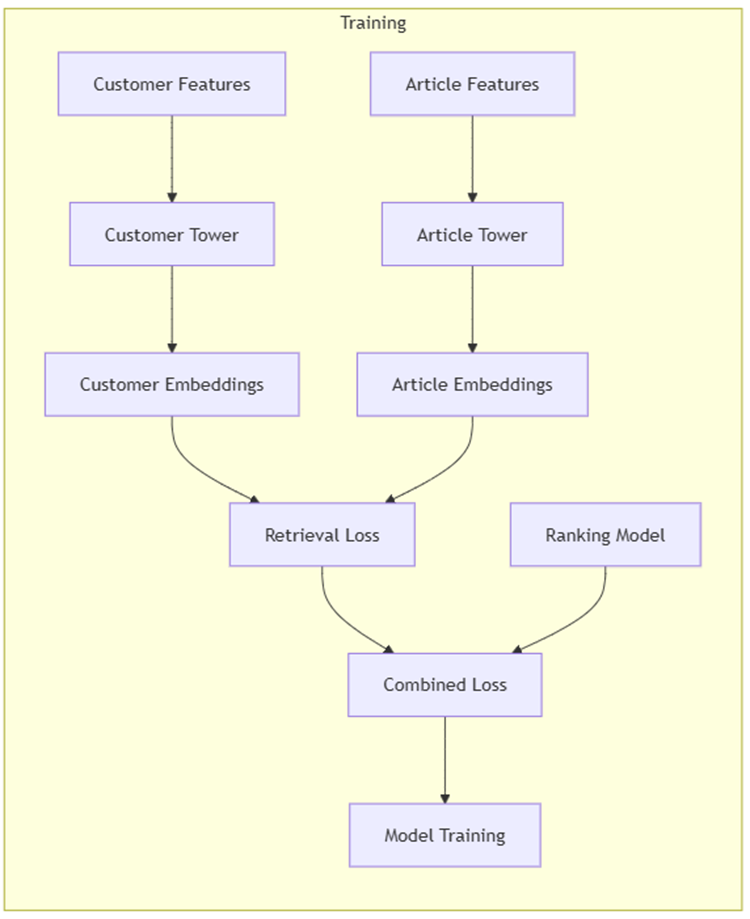

In [ ]:
@dataclass
class DataConfig:
    """Configuration for feature dimensions and model parameters."""

    customer_df: pd.DataFrame = field(repr=False)
    article_df: pd.DataFrame = field(repr=False)
    customer_feature_dim: int = field(init=False)
    article_feature_dim: int = field(init=False)

    embedding_dim: int = 32
    hidden_dims: Tuple[int, ...] = (128, 64)
    temperature: float = 0.1

    def __post_init__(self) -> None:
        """Calculate feature dimensions after initialization."""
        self.customer_feature_dim = len(
            self.customer_df.filter(regex=".*_cust$|.*_cust_.*").columns
        )
        self.article_feature_dim = len(
            self.article_df.filter(regex=".*_art$|.*_art_.*").columns
        )
        print(f"Customer features dimension: {self.customer_feature_dim}")
        print(f"Article features dimension: {self.article_feature_dim}")


class CustomerTower(tf.keras.Model):
    """Encodes customer features into embeddings."""

    def __init__(
        self,
        embedding_dim: int,
        hidden_dims: Tuple[int, ...],
        input_dim: int,
    ) -> None:
        super().__init__()

        self.sequential = tf.keras.Sequential(
            [tf.keras.layers.InputLayer(input_shape=(input_dim,))]
            + [tf.keras.layers.Dense(units, activation="relu") for units in hidden_dims]
            + [
                tf.keras.layers.Dense(embedding_dim),
                tf.keras.layers.LayerNormalization(),
            ]
        )

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return self.sequential(inputs)


class ItemTower(tf.keras.Model):
    """Encodes article features into embeddings."""

    def __init__(
        self,
        embedding_dim: int,
        hidden_dims: Tuple[int, ...],
        input_dim: int,
    ) -> None:
        super().__init__()

        self.sequential = tf.keras.Sequential(
            [tf.keras.layers.InputLayer(input_shape=(input_dim,))]
            + [tf.keras.layers.Dense(units, activation="relu") for units in hidden_dims]
            + [
                tf.keras.layers.Dense(embedding_dim),
                tf.keras.layers.LayerNormalization(),
            ]
        )

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return self.sequential(inputs)


class RankingModel(tf.keras.Model):
    """Ranks retrieved articles for a given customer."""

    def __init__(self, customer_dim: int, article_dim: int) -> None:
        super().__init__()

        self.customer_sequential = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(64, activation="relu"),
                tf.keras.layers.Dense(32, activation="relu"),
            ]
        )

        self.article_sequential = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(64, activation="relu"),
                tf.keras.layers.Dense(32, activation="relu"),
            ]
        )

        self.rating = tf.keras.Sequential(
            [
                tf.keras.layers.Dense(32, activation="relu"),
                tf.keras.layers.Dense(16, activation="relu"),
                tf.keras.layers.Dense(1, activation="sigmoid"),
            ]
        )

    def call(
        self, customer_features: tf.Tensor, article_features: tf.Tensor
    ) -> tf.Tensor:
        customer_embedding = self.customer_sequential(customer_features)
        article_embedding = self.article_sequential(article_features)
        return self.rating(tf.concat([customer_embedding, article_embedding], axis=1))


class TwoStageRecommender(tfrs.Model):
    """Two-stage recommendation model combining retrieval and ranking."""

    def __init__(self, config: DataConfig) -> None:
        super().__init__()

        self.query_model = CustomerTower(
            embedding_dim=config.embedding_dim,
            hidden_dims=config.hidden_dims,
            input_dim=config.customer_feature_dim,
        )

        self.candidate_model = ItemTower(
            embedding_dim=config.embedding_dim,
            hidden_dims=config.hidden_dims,
            input_dim=config.article_feature_dim,
        )

        self.ranking_model = RankingModel(
            config.customer_feature_dim, config.article_feature_dim
        )

        self.retrieval_task: tfrs.tasks.Retrieval = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(candidates=None),
            temperature=config.temperature,
        )

        self.ranking_task: tfrs.tasks.Ranking = tfrs.tasks.Ranking(
            loss=tf.keras.losses.BinaryCrossentropy(),
            metrics=[
                tf.keras.metrics.AUC(),
                tf.keras.metrics.Precision(),
                tf.keras.metrics.Recall(),
            ],
        )

    def compute_loss(
        self, features: Dict[str, tf.Tensor], training: bool = False
    ) -> tf.Tensor:
        customer_features = features["customer_features"]
        article_features = features["article_features"]
        ranking_labels = tf.cast(tf.reshape(features["label"], (-1, 1)), tf.float32)

        customer_embeddings = self.query_model(customer_features)
        article_embeddings = self.candidate_model(article_features)

        # Retrieval should only use true positive interactions.
        positive_mask = tf.squeeze(ranking_labels, axis=1) > 0.5
        positive_customer_embeddings = tf.boolean_mask(customer_embeddings, positive_mask)
        positive_article_embeddings = tf.boolean_mask(article_embeddings, positive_mask)

        retrieval_loss = tf.cond(
            tf.greater(tf.shape(positive_customer_embeddings)[0], 0),
            lambda: self.retrieval_task(
                positive_customer_embeddings, positive_article_embeddings
            ),
            lambda: tf.constant(0.0, dtype=tf.float32),
        )

        ranking_predictions = self.ranking_model(customer_features, article_features)
        ranking_loss = self.ranking_task(
            labels=ranking_labels, predictions=ranking_predictions
        )

        return retrieval_loss + ranking_loss


In [ ]:
def create_tf_dataset(
    customer_df: pd.DataFrame,
    article_df: pd.DataFrame,
    interactions_df: pd.DataFrame,
    batch_size: int = 256,
    negative_sample_boolean: bool = True,
    negative_samples: int = 4,
    seed: int = 42,
) -> tf.data.Dataset:
    """Creates TensorFlow dataset from pandas dataframes.

    Perform negative sampling if requested.
    """
    rng = np.random.default_rng(seed)

    merged_df = interactions_df.merge(customer_df, on="customer_id", how="left").merge(
        article_df, on="article_id", how="left"
    )

    if not negative_sample_boolean:
        customer_features = (
            merged_df.drop(columns=["customer_id"], errors="ignore")
            .filter(regex=".*_cust$|.*_cust_.*")
            .values.astype("float32")
        )
        article_features = (
            merged_df.drop(columns=["article_id"], errors="ignore")
            .filter(regex=".*_art$|.*_art_.*")
            .values.astype("float32")
        )

        dataset = tf.data.Dataset.from_tensor_slices(
            {
                "customer_features": customer_features,
                "article_features": article_features,
                "label": tf.ones(len(merged_df), dtype=tf.float32),
            }
        )

    else:
        positive_customer_features = (
            merged_df.drop(columns=["customer_id"], errors="ignore")
            .filter(regex=".*_cust$|.*_cust_.*")
            .values.astype("float32")
        )
        positive_article_features = (
            merged_df.drop(columns=["article_id"], errors="ignore")
            .filter(regex=".*_art$|.*_art_.*")
            .values.astype("float32")
        )

        all_customer_features = [positive_customer_features]
        all_article_features = [positive_article_features]
        all_labels = [np.ones(len(merged_df), dtype="float32")]

        article_feature_only = (
            article_df.drop(columns=["article_id"], errors="ignore")
            .filter(regex=".*_art$|.*_art_.*")
            .values.astype("float32")
        )

        for _ in range(negative_samples):
            negative_indices = rng.integers(
                low=0, high=len(article_feature_only), size=len(merged_df)
            )
            negative_article_features = article_feature_only[negative_indices]

            all_customer_features.append(positive_customer_features)
            all_article_features.append(negative_article_features)
            all_labels.append(np.zeros(len(merged_df), dtype="float32"))

        customer_features = np.concatenate(all_customer_features)
        article_features = np.concatenate(all_article_features)
        labels = np.concatenate(all_labels)

        dataset = tf.data.Dataset.from_tensor_slices(
            {
                "customer_features": customer_features,
                "article_features": article_features,
                "label": labels,
            }
        )

    return dataset.shuffle(10000, seed=seed).batch(batch_size).prefetch(tf.data.AUTOTUNE)


def plot_training_metrics(history: dict) -> None:
    """
    Plot training metrics from model history.
    Args:
        history: Training history dictionary from model.fit()
    """
    print("Available metrics:", history.keys())

    plt.figure(figsize=(12, 4))

    loss_key = [metric for metric in history.keys() if "loss" in metric][0]
    precision_key = [metric for metric in history.keys() if "precision" in metric][0]
    auc_key = [metric for metric in history.keys() if "auc" in metric][0]

    plt.subplot(1, 3, 1)
    plt.plot(history[loss_key])
    plt.title("Total Loss Over Time")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history[precision_key])
    plt.title("Precision")
    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history[auc_key])
    plt.title("AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


def train_model(
    customer_df: pd.DataFrame,
    article_df: pd.DataFrame,
    interactions_df: pd.DataFrame,
    epochs: int = 5,
    batch_size: int = 256,
    seed: int = 42,
) -> TwoStageRecommender:
    """Trains the two-stage recommender model."""
    config = DataConfig(customer_df=customer_df, article_df=article_df)

    train_dataset = create_tf_dataset(
        customer_df,
        article_df,
        interactions_df,
        batch_size=batch_size,
        negative_sample_boolean=True,
        seed=seed,
    )

    model = TwoStageRecommender(config)

    article_feature_frame = article_df.drop_duplicates(subset=["article_id"])
    article_features = (
        article_feature_frame.drop(columns=["article_id"], errors="ignore")
        .filter(regex=".*_art$|.*_art_.*")
        .values.astype("float32")
    )

    article_dataset = tf.data.Dataset.from_tensor_slices(article_features).batch(128)

    model.retrieval_task.factorized_metrics = tfrs.metrics.FactorizedTopK(
        candidates=article_dataset.map(model.candidate_model)
    )

    model.compile(optimizer=tf.keras.optimizers.Adam(0.001))
    callbacks = [
        EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)
    ]
    history = model.fit(train_dataset, epochs=epochs, callbacks=callbacks)

    plot_training_metrics(history.history)

    return model


In [ ]:
# Train model.
train_epochs = int(os.getenv("HNM_EPOCHS", "30"))
train_batch_size = int(os.getenv("HNM_BATCH_SIZE", "256"))

model = train_model(
    customer_df=customer_train,
    article_df=article_train,
    interactions_df=interactions_train,
    epochs=train_epochs,
    batch_size=train_batch_size,
    seed=SEED,
)


# Inference


1. Finding Initial Matches (Retrieval):
  - Turn customer and product information into a tensor for the model
  - Use our trained model to find similarities between customers and products
  - Pick the top k*4 (k defined by us) potential matches for each customer (we get extra since we'll filter some out)

2. Refining the Recommendations:
  - Remove products the customer already bought
  - If we filtered out too many items, look for more potential matches
  - Use our ranking system to score the remaining products
  - Pick the top n best-scoring items as final recommendations

We iterate through different customers and repeat the stps above, using the top-k matches from the first step as our initial recommendations.:

we make sure we don't recommend products someone already owns

This two-step approach helps us efficiently find good matches from thousands of products while keeping recommendations personalized.

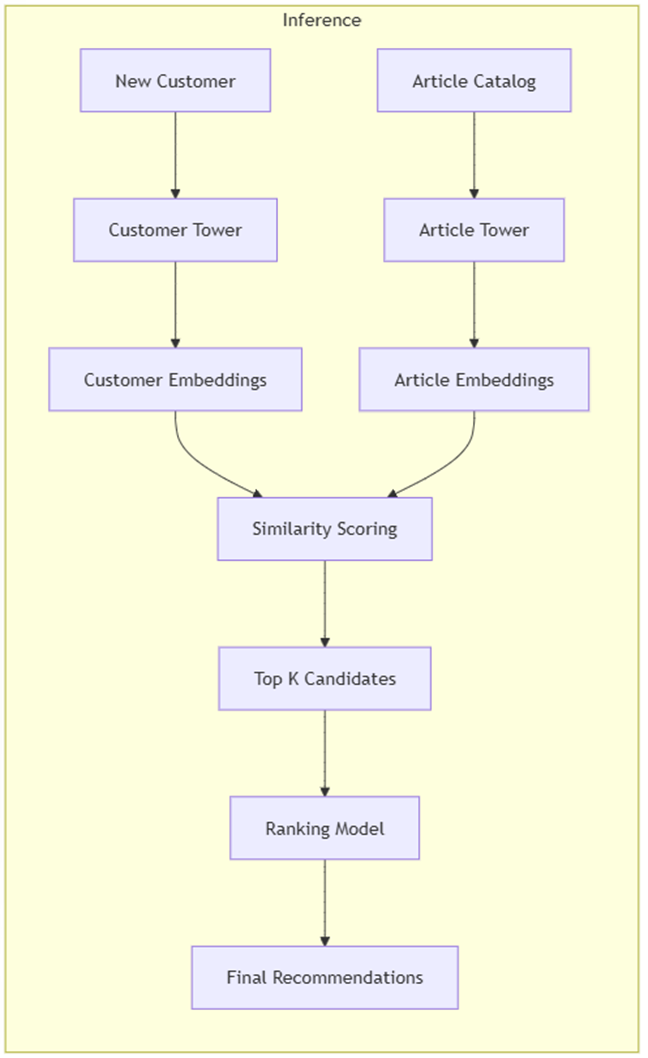

In [ ]:
def get_recommendations_multiple_customers(
    model: TwoStageRecommender,
    customer_features,
    article_df,
    interaction_df,
    customer_ids: List[str],
    k=30,
):
    """
    Get top-k recommendations for multiple customers, excluding previous purchases.
    """
    customer_ids = list(customer_ids)

    customer_purchases = {
        cust_id: set(
            interaction_df.loc[interaction_df["customer_id"] == cust_id, "article_id"]
        )
        for cust_id in customer_ids
    }

    customer_features_tensor = tf.convert_to_tensor(
        customer_features.values.astype("float32")
    )

    article_ids = article_df["article_id"].values
    article_features = article_df.filter(regex=".*_art$|.*_art_.*").values
    article_features_tensor = tf.convert_to_tensor(article_features.astype("float32"))

    customer_embeddings = model.query_model(customer_features_tensor)
    article_embeddings = model.candidate_model(article_features_tensor)

    retrieval_scores = tf.matmul(customer_embeddings, article_embeddings, transpose_b=True)

    initial_k = min(k * 4, article_embeddings.shape[0])
    _, top_indices = tf.math.top_k(retrieval_scores, k=initial_k)

    all_final_scores = []
    all_final_indices = []

    for customer_index_position, customer_id in enumerate(customer_ids):
        purchased_items = customer_purchases[customer_id]
        candidate_indices = top_indices[customer_index_position].numpy()

        candidate_article_ids = article_ids[candidate_indices]
        mask = np.array([article_id not in purchased_items for article_id in candidate_article_ids])
        filtered_indices = candidate_indices[mask]

        if len(filtered_indices) < k * 2:
            expanded_k = min(k * 6, article_embeddings.shape[0])
            _, more_indices = tf.math.top_k(
                retrieval_scores[customer_index_position],
                k=expanded_k,
            )
            more_indices = more_indices.numpy()
            more_article_ids = article_ids[more_indices]
            more_mask = np.array(
                [article_id not in purchased_items for article_id in more_article_ids]
            )
            more_filtered = more_indices[more_mask]
            filtered_indices = np.unique(
                np.concatenate([filtered_indices, more_filtered])
            )[: k * 2]

        if len(filtered_indices) == 0:
            all_final_scores.append(tf.zeros([k], dtype=tf.float32))
            all_final_indices.append(tf.zeros([k], dtype=tf.int32))
            continue

        candidate_features = tf.gather(article_features_tensor, filtered_indices)

        current_customer_features = tf.repeat(
            customer_features_tensor[customer_index_position : customer_index_position + 1],
            repeats=[len(candidate_features)],
            axis=0,
        )

        ranking_scores = model.ranking_model(current_customer_features, candidate_features)

        final_k = min(k, len(filtered_indices))
        final_scores, final_indices = tf.math.top_k(ranking_scores[:, 0], k=final_k)

        if final_k < k:
            final_scores = tf.pad(final_scores, [[0, k - final_k]])
            final_indices = tf.pad(final_indices, [[0, k - final_k]])

        final_article_indices = tf.gather(filtered_indices, final_indices)

        all_final_scores.append(final_scores)
        all_final_indices.append(final_article_indices)

    final_scores = tf.stack(all_final_scores)
    final_article_indices = tf.stack(all_final_indices)

    return final_scores.numpy(), final_article_indices.numpy(), customer_ids


In [ ]:
# Create pre-required datasets
article_df_inference = merge_list_of_datasets(
    [article_train, article_val, article_test]
).drop_duplicates(subset=["article_id"]).reset_index(drop=True)

# Use historical interactions for filtering seen items.
history_interactions = merge_list_of_datasets([interactions_train, interactions_val])

# Evaluate on held-out test interactions.
evaluation_interactions = interactions_test

start_position, end_position = 0, 3000

# Inference customers come from test split.
test_customer = customer_test.filter(regex=".*_cust$|.*_cust_.*").iloc[
    start_position:end_position
]
customer_id_eval = customer_test["customer_id"].iloc[start_position:end_position].tolist()


In [ ]:
# Get recommendations
scores, recommended_article_indices, customer_id_list = get_recommendations_multiple_customers(
    model=model,
    customer_features=test_customer,
    article_df=article_df_inference,
    interaction_df=history_interactions,
    customer_ids=customer_id_eval,
)


In [ ]:
# Print sample recommendations.
article_ids = article_df_inference["article_id"].values
predicted_items = article_ids[recommended_article_indices]

max_users_to_print = int(os.getenv("HNM_MAX_USERS_TO_PRINT", "10"))
users_to_print = min(len(test_customer), max_users_to_print)

for i in range(users_to_print):
    print()
    print(f"Customer {i}:")
    print(f"Recommendation scores: {scores[i]}")
    print(f"Recommended articles: {predicted_items[i]}")

if len(test_customer) > users_to_print:
    print()
    print(f"Displayed {users_to_print} of {len(test_customer)} customers.")


# Recommendation System Evaluation

We evaluate the recommendation system's performance using three standard metrics at K=10, 20, and 30:

1. Evaluation Setup:
  - Creates ground truth from validation transaction data
  - Maps customer IDs to their actual purchases
  - Establishes baseline statistics for comparison

2. Performance Metrics:
  - Precision@K: Accuracy of recommendations
  - Recall@K: Coverage of relevant items
  - NDCG@K: Quality of ranking order

3. Results Analysis:
  - Generates summary metrics across all users
  - Visualizes metric distributions
  - Provides per-customer performance analysis
  - Enables comparison across different K values

The framework offers both aggregate and detailed performance insights, helping identify areas for model improvement.


In [ ]:
class RecommenderEvaluator:
    """Evaluate recommendation quality for top-k predictions."""

    def __init__(self, test_data: pd.DataFrame) -> None:
        self.data = test_data
        self.truth = self.make_truth_dict()
        self.last_results = None

    def make_truth_dict(self) -> Dict[Any, set]:
        """Map customer_id -> set of purchased article_ids."""
        truth = {}
        for _, row in self.data.iterrows():
            truth.setdefault(row["customer_id"], set()).add(row["article_id"])
        return truth

    @staticmethod
    def calc_metrics(preds: np.ndarray, real_items: set, k: int) -> Dict[str, float]:
        """Compute Precision@k, Recall@k, and NDCG@k for one user."""
        preds = preds[:k]
        hits = len(set(preds) & real_items)

        prec = hits / k if k > 0 else 0.0
        rec = hits / len(real_items) if real_items else 0.0

        rel = [1 if p in real_items else 0 for p in preds]
        dcg = rel[0] if rel else 0.0
        for i in range(1, len(rel)):
            dcg += rel[i] / np.log2(i + 2)

        ideal_rel = [1] * min(k, len(real_items))
        idcg = ideal_rel[0] if ideal_rel else 0.0
        for i in range(1, len(ideal_rel)):
            idcg += 1 / np.log2(i + 2)

        ndcg = dcg / idcg if idcg > 0 else 0.0

        return {f"p@{k}": prec, f"r@{k}": rec, f"ndcg@{k}": ndcg}

    def evaluate(
        self,
        all_preds: np.ndarray,
        customers: List[Any],
        ks: List[int] = [10, 20],
    ) -> Dict[str, Dict[str, float]]:
        """Evaluate recommendations for multiple users at different k."""
        results = {"by_user": {}, "avg": {}}

        for idx, cust in enumerate(customers):
            if cust not in self.truth:
                continue

            preds = all_preds[idx]
            true_items = self.truth[cust]
            user_results = {}

            for k in ks:
                user_results.update(self.calc_metrics(preds, true_items, k))

            results["by_user"][cust] = user_results

        all_metrics = {}
        for k in ks:
            p = [u[f"p@{k}"] for u in results["by_user"].values()]
            r = [u[f"r@{k}"] for u in results["by_user"].values()]
            n = [u[f"ndcg@{k}"] for u in results["by_user"].values()]

            all_metrics[f"precision@{k}"] = float(np.mean(p)) if p else 0.0
            all_metrics[f"recall@{k}"] = float(np.mean(r)) if r else 0.0
            all_metrics[f"ndcg@{k}"] = float(np.mean(n)) if n else 0.0

        results["avg"] = all_metrics
        del results["by_user"]
        self.last_results = results
        return results

    def get_report(self) -> pd.DataFrame:
        """Return averaged metrics as a DataFrame."""
        if not self.last_results:
            return pd.DataFrame(
                {"metric": ["status"], "value": ["No results yet. Run evaluate()."]}
            )

        return pd.DataFrame(
            {
                "metric": list(self.last_results["avg"].keys()),
                "value": list(self.last_results["avg"].values()),
            }
        )


In [ ]:
evaluator = RecommenderEvaluator(evaluation_interactions)
results = evaluator.evaluate(predicted_items, customer_id_list, ks=[10, 20])
results_df = evaluator.get_report()


In [ ]:
# Print evaluation metrics.
print("Evaluation results:")
print(results_df.to_string(index=False))


### The End